# Discovering conservative patterns in the results of probing RNA-protein binding sites

 - Mateusz Tabaszewski
 - Bartłomiej Pukacki
 - Adam Mielniczuk
 - Krzysztof Weber

## TODO:
 - Double check because I have no idea if its correct
 - Expand/Fix clustering, right now it sucks
 - Add short descriptions/conculsions to each section

## Imports

In [1]:
from pathlib import Path
from typing import Union
import glob
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import itertools
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import stumpy
from tqdm import tqdm

## Functions

### Preprocessing

In [2]:
def transform_to_dataframes(promising_binding_sites):
    result_dfs = {}
    
    for length, motifs in promising_binding_sites.items():
        rows = []
        for motif in motifs:
            row = {}
            sequence = ""
            for i, (val, char) in enumerate(motif):
                row[f'val{i+1}'] = val
                sequence += str(char)
            row['str_representation'] = sequence
            rows.append(row)
        df = pd.DataFrame(rows)
        result_dfs[length] = df
    return result_dfs

def read_protein_pattern(note_path: Path):
    parsed_file = []
    with open(note_path, "r") as note_file:
        data = note_file.read().strip().split("\n")
        for example in data:
            try:
                value = float(example.split("\t")[0])
            except Exception:
                value = None
            character = example.split("\t")[1]
            parsed_file.append((value, character))
    return parsed_file

def extract_motiff_length(motiff_representation: Union[list, tuple], expand: int=2):
    acceptable_lengths = []
    for i in range(expand+1):
        acceptable_lengths.append(len(motiff_representation)+i)
    return acceptable_lengths

def find_all_txts(dir: Path):
    txts = glob.glob("*.txt", root_dir=dir)
    return txts

def sliding_window_reactivity(protein_pattern: list, window_size: int, min_reactivity: float=1.0):
    results = []
    if window_size > len(protein_pattern):
        return results
    for i in range(len(protein_pattern) - window_size + 1):
        protein_slice = protein_pattern[i: i+window_size]
        for val in protein_slice:
            if val[0] is not None and val[0]>= min_reactivity:
                results.append(protein_slice)
                break
    return results

### Clustering

In [3]:
def get_scaled_features(df, val_cols):
    scaler = StandardScaler()
    return scaler.fit_transform(df[val_cols].values)

def optimize_kmeans(data, max_k):
    results = []
    
    for k in range(3, max_k + 1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        score = silhouette_score(data, labels)
        
        results.append({"k": k, "score": score, "model": kmeans, "labels": labels})
        print(f"Clusters: {k} | Silhouette Score: {score:.4f}")

    best_run = max(results, key=lambda x: x['score'])
    return best_run


def optimize_agglomerative(data, k_range=None, linkages=None, metrics=None):
    results = []
    for linkage, k in itertools.product(linkages, k_range):
        current_metrics = ['euclidean'] if linkage == 'ward' else metrics
        
        for metric in current_metrics:
            try:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage, metric=metric)
                labels = model.fit_predict(data)
                
                score = silhouette_score(data, labels)
                
                results.append({
                    'linkage': linkage,
                    'k': k,
                    'metric': metric,
                    'silhouette_score': score,
                    'labels': labels,
                })
            except Exception as e:
                continue

    results_df = pd.DataFrame(results).sort_values(by='silhouette_score', ascending=False)
    best_config = results_df.iloc[0].to_dict()
    return best_config, results_df

def optimize_dbscan(data, eps_range=None, min_samples_range=None):
    results = []

    for eps, min_samples in itertools.product(eps_range, min_samples_range):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(data)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            score = silhouette_score(data, labels)
            noise_ratio = np.sum(labels == -1) / len(labels)     
            results.append({
                'eps': round(eps, 2),
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'noise_ratio': round(noise_ratio, 3),
                'silhouette_score': score,
                'labels': labels,
            })

    if not results:
        return None, pd.DataFrame()

    results_df = pd.DataFrame(results).sort_values(by='silhouette_score', ascending=False)
    best_config = results_df.iloc[0].to_dict()
    
    return best_config, results_df

def plot_cluster_grid(df, feature_cols, method_map, n_cols=3, overall_title="Clustering Comparison"):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df[feature_cols])
    
    pca = PCA(n_components=2)
    components = pca.fit_transform(scaled_data)
    
    df_plot = df.copy()
    df_plot['PC1'] = components[:, 0]
    df_plot['PC2'] = components[:, 1]
    
    methods = list(method_map.keys())
    n_rows = (len(methods) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(methods):
        sns.scatterplot(
            data=df_plot, x='PC1', y='PC2', 
            hue=col, palette='tab10', ax=axes[i], legend='brief'
        )
        axes[i].set_title(method_map.get(col, col), fontweight='bold')
        axes[i].set_xlabel("Principal Component 1")
        axes[i].set_ylabel("Principal Component 2")
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle(overall_title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def get_top_3_clusters(df, label_col='label', ignore_negative=True, min_size=3):
    temp_df = df.copy()
    if ignore_negative:
        temp_df = temp_df[temp_df[label_col] >= 0]

    counts = temp_df[label_col].value_counts()
    valid_labels = counts[counts >= min_size].nlargest(3).index.tolist()
    
    results = [temp_df[temp_df[label_col] == label] for label in valid_labels]
    
    while len(results) < 3:
        results.append(None)

    return results[0], results[1], results[2]


### Consensus and Results

In [4]:
def get_cluster_consensus(cluster_df, val_cols):
    if cluster_df is None or cluster_df.empty or len(cluster_df) < 2:
        return None
    
    data = cluster_df[val_cols].values.astype(np.float64)
    m = data.shape[1]  # motif length
    Ts = [row for row in data]  # list of 1-D arrays
    
    try:
        radius, Ts_idx, subseq_idx = stumpy.ostinato(Ts, m=m)
        consensus = Ts[Ts_idx][subseq_idx : subseq_idx + m]
    except Exception:
        dist_matrix = cdist(data, data, metric='euclidean')
        medoid_idx = np.argmin(dist_matrix.sum(axis=1))
        consensus = data[medoid_idx]
    
    return consensus

def calculate_ssf(seq1, seq2):
    score = 0
    purines = {'A', 'G'}
    pyrimidines = {'C', 'T', 'U'}
    
    for c1, c2 in zip(seq1, seq2):
        if c1 == c2:
            score += 2
        elif (c1 in purines and c2 in purines) or (c1 in pyrimidines and c2 in pyrimidines):
            score += 1
    return score

def build_expected_seq(base_seq, target_len):
    base_len = len(base_seq)
    diff = target_len - base_len
    if diff == 0:
        return base_seq
    elif diff == 1:
        return "N" + base_seq
    elif diff == 2:
        return "N" + base_seq + "N"
    else:
        # General fallback: pad evenly
        return ("N" * (diff // 2)) + base_seq + ("N" * (diff - diff // 2))

def search_transcript_for_consensus(consensus_profile, transcript_path, original_expected_seq):
    data = pd.read_csv(transcript_path, sep='\s+', names=['fshape', 'nuc', 'extra'], header=None)
    fshape_signal = pd.to_numeric(data['fshape'], errors='coerce').fillna(0.0).values.astype(np.float64)
    nucleotides = data['nuc'].tolist()
    distance_profile = stumpy.mass(consensus_profile, fshape_signal)
    threshold = 2.5
    match_indices = np.where(distance_profile <= threshold)[0]
    
    results = []
    m = len(consensus_profile)
    
    for idx in match_indices:
        znEd = distance_profile[idx]
        match_seq = "".join(nucleotides[idx : idx + m])
        ssf = calculate_ssf(match_seq, original_expected_seq[:m])
        aS = (10 * znEd) - ssf
        
        results.append({
            'motif_sequence': match_seq,
            'position_range': f"{idx}-{idx + m}",
            'source_file': transcript_path.name,
            'znEd': round(znEd, 4),
            'ssf': ssf,
            'aS': round(aS, 4),
            'consensus_used': list(np.round(consensus_profile, 3)),
            'consensus_len': m
        })
        
    return pd.DataFrame(results)

<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_216950/788036633.py:45: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(transcript_path, sep='\s+', names=['fshape', 'nuc', 'extra'], header=None)


## HNRNPA2B1

### Data Loading

In [5]:
protein_path_1 = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPA2B1/hnrnpa2b1_expected_pattern.txt")
motiff_1 = read_protein_pattern(protein_path_1)
motiff_1_lengths = extract_motiff_length(motiff_1)
motiff_1_lengths

[11, 12, 13]

### Extracting Promising Motiffs

In [6]:
binging_sites_dir = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPA2B1/hnrnpa2b1_binding_sites_fshape")
binding_sites_txts = find_all_txts(binging_sites_dir)
binding_sites_1 = []

for site in binding_sites_txts:
    full_path = Path(binging_sites_dir, site)
    out = read_protein_pattern(full_path)
    binding_sites_1.append(out)


promising_binding_sites_1 = {}
for window_size in motiff_1_lengths:
    promising_binding_sites_1[window_size] = []
    for binding_site in binding_sites_1:
        outs = sliding_window_reactivity(binding_site, window_size=window_size)
        if len(outs) == 0:
            continue
        for out in outs:
            promising_binding_sites_1[window_size].append(out)

In [7]:
binding_sites_df_1= transform_to_dataframes(promising_binding_sites_1)

for key in binding_sites_df_1:
    binding_sites_df_1[key] = binding_sites_df_1[key].dropna()

In [8]:
binding_sites_df_1[11].head(5)

,val1,val2,val3,val4,val5,val6,val7,val8,val9,val10,val11,str_representation
0,0.384566,-0.207538,0.396215,-0.146470,0.201688,0.303140,-1.866589,0.006406,0.073847,-0.491765,1.000000,CTGGGGGTTGG
1,-0.207538,0.396215,-0.146470,0.201688,0.303140,-1.866589,0.006406,0.073847,-0.491765,1.000000,0.798732,TGGGGGTTGGT
11,0.530469,-0.692864,0.038456,0.124882,-0.019156,-0.654885,1.005952,3.502356,-0.468606,-0.230392,-1.566579,CTTTGGAAGTA
12,-0.692864,0.038456,0.124882,-0.019156,-0.654885,1.005952,3.502356,-0.468606,-0.230392,-1.566579,-0.047094,TTTGGAAGTAA
13,0.038456,0.124882,-0.019156,-0.654885,1.005952,3.502356,-0.468606,-0.230392,-1.566579,-0.047094,0.644525,TTGGAAGTAAT


## Clustering

In [9]:
val_cols_11 = [f"val{i}" for i in range(1, 12)]
X_11 = get_scaled_features(binding_sites_df_1[11], val_cols_11)

val_cols_12 = [f"val{i}" for i in range(1, 13)]
X_12 = get_scaled_features(binding_sites_df_1[12], val_cols_12)

val_cols_13 = [f"val{i}" for i in range(1, 14)]
X_13 = get_scaled_features(binding_sites_df_1[13], val_cols_13)

#### Length 11

In [10]:
best_run_11 = optimize_kmeans(X_11, max_k=20)
binding_sites_df_1[11]["k_means_labels"] = best_run_11["labels"]

Clusters: 3 | Silhouette Score: 0.1061
Clusters: 4 | Silhouette Score: 0.1083
Clusters: 5 | Silhouette Score: 0.0904
Clusters: 6 | Silhouette Score: 0.0891
Clusters: 7 | Silhouette Score: 0.0899
Clusters: 8 | Silhouette Score: 0.0995
Clusters: 9 | Silhouette Score: 0.0868
Clusters: 10 | Silhouette Score: 0.0934
Clusters: 11 | Silhouette Score: 0.0839
Clusters: 12 | Silhouette Score: 0.0849
Clusters: 13 | Silhouette Score: 0.0851
Clusters: 14 | Silhouette Score: 0.0812
Clusters: 15 | Silhouette Score: 0.0928
Clusters: 16 | Silhouette Score: 0.0926
Clusters: 17 | Silhouette Score: 0.0820
Clusters: 18 | Silhouette Score: 0.0827
Clusters: 19 | Silhouette Score: 0.0775
Clusters: 20 | Silhouette Score: 0.0883


In [11]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_11, best_run_11_df = optimize_agglomerative(X_11, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_1[11]["agglomerative_labels"] = best_run_11["labels"]
best_run_11_df.head(5)

,linkage,k,metric,silhouette_score,labels
24,average,3,euclidean,0.782299,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
43,single,3,manhattan,0.778215,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.773920,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
46,single,4,manhattan,0.773723,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
45,single,4,euclidean,0.773723,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [12]:
best_run_11, best_run_11_df = optimize_dbscan(X_11, eps_range=np.arange(0.1, 1.1, 0.1), min_samples_range=range(3, 10))
binding_sites_df_1[11]["dbscan_labels"] = best_run_11["labels"]
best_run_11_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
29,1.0,6,3,0.684,-0.193548,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
31,1.0,8,2,0.712,-0.226340,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
32,1.0,9,2,0.720,-0.238525,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
30,1.0,7,3,0.699,-0.239992,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
26,0.9,7,2,0.806,-0.251377,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."


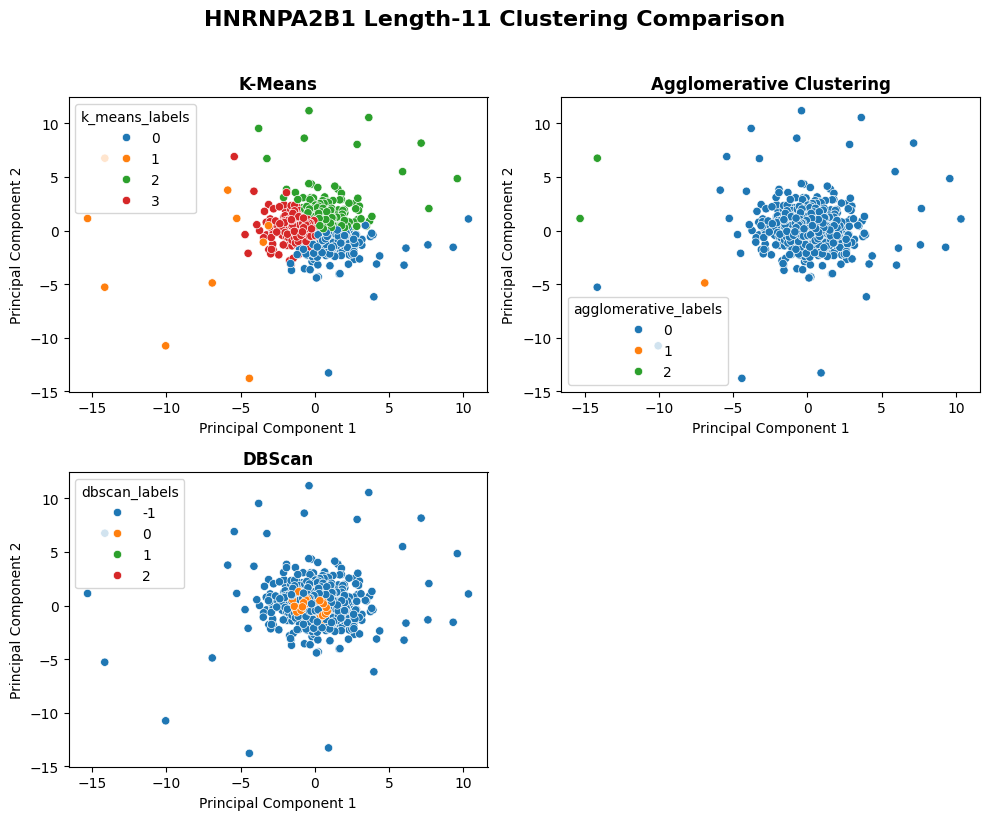

In [13]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan"
}
feature_cols=[f"val{i}" for i in range(1, 12)]

plot_cluster_grid(binding_sites_df_1[11].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPA2B1 Length-11 Clustering Comparison")

#### Length 12

In [14]:
best_run_12 = optimize_kmeans(X_12, max_k=20)
binding_sites_df_1[12]["k_means_labels"] = best_run_12["labels"]

Clusters: 3 | Silhouette Score: 0.1029
Clusters: 4 | Silhouette Score: 0.0874
Clusters: 5 | Silhouette Score: 0.0852
Clusters: 6 | Silhouette Score: 0.0835
Clusters: 7 | Silhouette Score: 0.0804
Clusters: 8 | Silhouette Score: 0.0803
Clusters: 9 | Silhouette Score: 0.0830
Clusters: 10 | Silhouette Score: 0.0780
Clusters: 11 | Silhouette Score: 0.0847
Clusters: 12 | Silhouette Score: 0.0789
Clusters: 13 | Silhouette Score: 0.0719
Clusters: 14 | Silhouette Score: 0.0849
Clusters: 15 | Silhouette Score: 0.0837
Clusters: 16 | Silhouette Score: 0.0661
Clusters: 17 | Silhouette Score: 0.0755
Clusters: 18 | Silhouette Score: 0.0790
Clusters: 19 | Silhouette Score: 0.0850
Clusters: 20 | Silhouette Score: 0.0796


In [15]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_12, best_run_12_df = optimize_agglomerative(X_12, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_1[12]["agglomerative_labels"] = best_run_12["labels"]
best_run_12_df.head(5)

,linkage,k,metric,silhouette_score,labels
24,average,3,euclidean,0.774396,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
43,single,3,manhattan,0.770719,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
45,single,4,euclidean,0.764970,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
46,single,4,manhattan,0.764970,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.764906,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [16]:
best_run_12, best_run_12_df = optimize_dbscan(X_12, eps_range=np.arange(0.1, 1.1, 0.1), min_samples_range=range(3, 10))
binding_sites_df_1[12]["dbscan_labels"] = best_run_12["labels"]
best_run_12_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
25,1.0,6,2,0.791,-0.229552,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
27,1.0,8,2,0.820,-0.244948,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
28,1.0,9,2,0.824,-0.246295,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
20,0.9,8,2,0.897,-0.253435,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
21,0.9,9,2,0.901,-0.255945,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."


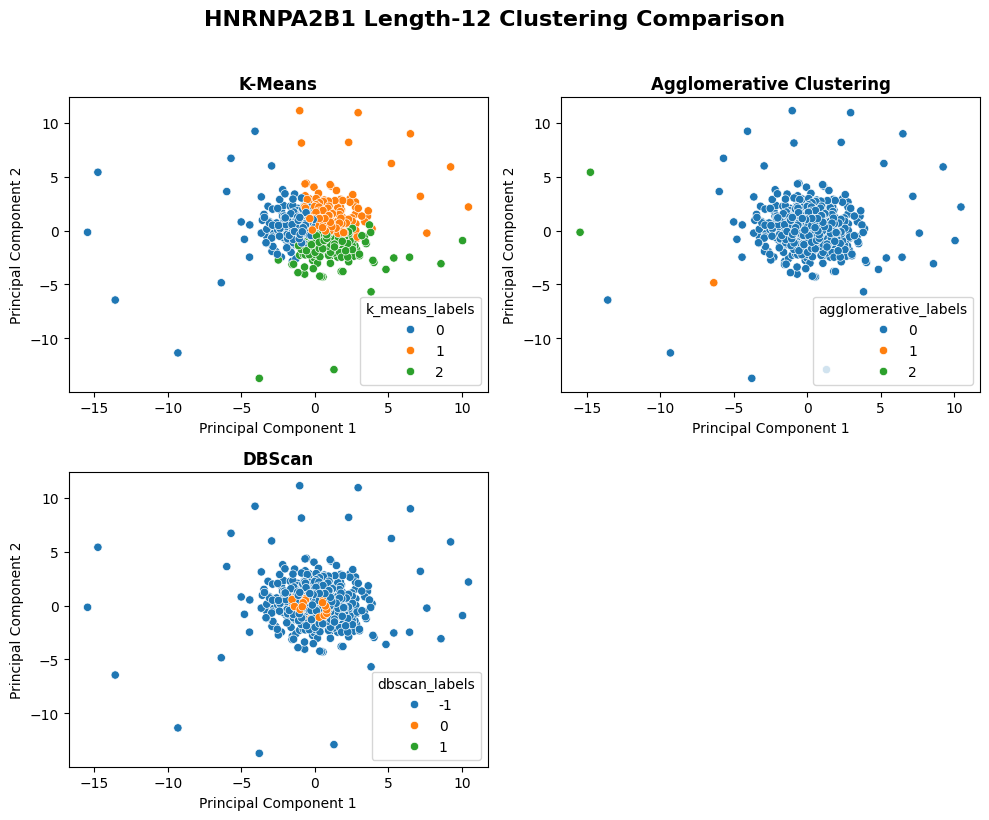

In [17]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan"
}
feature_cols=[f"val{i}" for i in range(1, 13)]

plot_cluster_grid(binding_sites_df_1[12].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPA2B1 Length-12 Clustering Comparison")

#### Length 13

In [18]:
best_run_13 = optimize_kmeans(X_13, max_k=20)
binding_sites_df_1[13]["k_means_labels"] = best_run_13["labels"]

Clusters: 3 | Silhouette Score: 0.0959
Clusters: 4 | Silhouette Score: 0.0834
Clusters: 5 | Silhouette Score: 0.0789
Clusters: 6 | Silhouette Score: 0.0755
Clusters: 7 | Silhouette Score: 0.0780
Clusters: 8 | Silhouette Score: 0.0848
Clusters: 9 | Silhouette Score: 0.0602
Clusters: 10 | Silhouette Score: 0.0764
Clusters: 11 | Silhouette Score: 0.0785
Clusters: 12 | Silhouette Score: 0.0732
Clusters: 13 | Silhouette Score: 0.0756
Clusters: 14 | Silhouette Score: 0.0758
Clusters: 15 | Silhouette Score: 0.0713
Clusters: 16 | Silhouette Score: 0.0758
Clusters: 17 | Silhouette Score: 0.0725
Clusters: 18 | Silhouette Score: 0.0683
Clusters: 19 | Silhouette Score: 0.0698
Clusters: 20 | Silhouette Score: 0.0799


In [19]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_13, best_run_13_df = optimize_agglomerative(X_13, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_1[13]["agglomerative_labels"] = best_run_13["labels"]
best_run_13_df.head(5)

,linkage,k,metric,silhouette_score,labels
24,average,3,euclidean,0.766648,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
43,single,3,manhattan,0.762494,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.756826,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
46,single,4,manhattan,0.756705,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
45,single,4,euclidean,0.756705,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [20]:
best_run_13, best_run_13_df = optimize_dbscan(X_13, eps_range=np.arange(0.1, 1.1, 0.1), min_samples_range=range(3, 10))
binding_sites_df_1[13]["dbscan_labels"] = best_run_13["labels"]
best_run_13_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
22,1.0,7,2,0.880,-0.236961,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
23,1.0,8,3,0.888,-0.264509,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
15,0.9,6,2,0.918,-0.265607,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
14,0.9,5,2,0.911,-0.268556,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."
24,1.0,9,3,0.894,-0.269446,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -..."


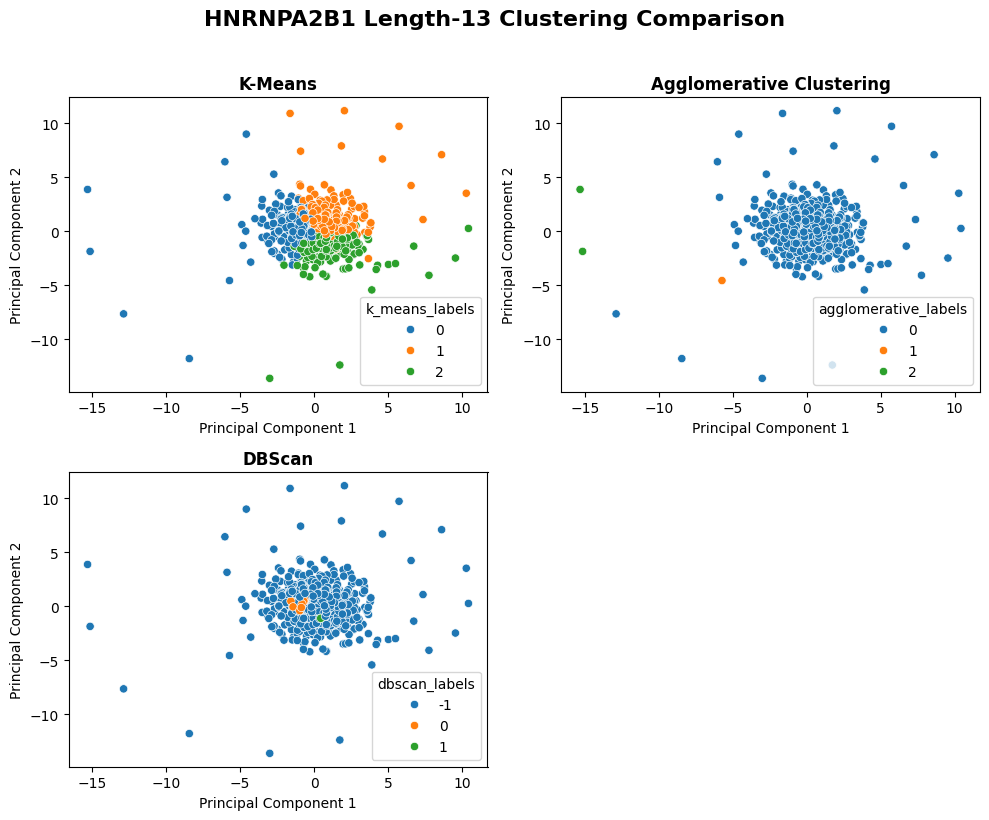

In [21]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan"
}
feature_cols=[f"val{i}" for i in range(1, 14)]

plot_cluster_grid(binding_sites_df_1[13].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPA2B1 Length-13 Clustering Comparison")

#### Full Results

In [22]:
fshape_dir = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPA2B1/hnrnpa2b1_search_fshape")
val_cols = [f"val{i}" for i in range(1, 12)]
base_expected_seq = "".join([char for val, char in motiff_1])
final_findings = []

for window_size in tqdm(motiff_1_lengths):
    top_clusters = get_top_3_clusters(binding_sites_df_1[window_size],
                                      label_col="k_means_labels")
    val_cols = [f"val{i}" for i in range(1, window_size + 1)]
    expected_seq = build_expected_seq(base_expected_seq, window_size)
    final_findings = []

    for cluster_df in top_clusters:
        consensus = get_cluster_consensus(cluster_df, val_cols)
        if consensus is None:
            continue
        for file_path in fshape_dir.glob("*.txt"):
            match_df = search_transcript_for_consensus(
                consensus, file_path, expected_seq
            )
            final_findings.append(match_df)

100%|██████████| 3/3 [00:50<00:00, 16.86s/it]


In [23]:
report_df = pd.concat(final_findings).sort_values('aS')
report_df.head(15)

,motif_sequence,position_range,source_file,znEd,ssf,aS,consensus_used,consensus_len
13,GGCGGGGCTAAAG,678-691,hnrnpa2b1_NM_001127230_AURKAIP1.txt,0.8804,10,-1.1958,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
6,TCATGGCCAAGGT,661-674,hnrnpa2b1_NM_006601_PTGES3.txt,0.8312,8,0.3119,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
20,CGGGTGGCCAGTT,1169-1182,hnrnpa2b1_NM_005918_MDH2.txt,0.8444,8,0.4436,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
12,CCCTGGGGCAAAA,726-739,hnrnpa2b1_NM_001984_ESD.txt,0.8687,8,0.6870,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
33,CCTGAGGCTGAAG,847-860,hnrnpa2b1_NM_001195129_PRSS56.txt,0.8888,8,0.8877,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
14,CCCAGCCCTGAGA,589-602,hnrnpa2b1_NM_014222_NDUFA8.txt,0.8942,8,0.9416,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
1,GGAAGAGATGGAT,363-376,hnrnpa2b1_NM_004939_DDX1.txt,1.1075,10,1.0746,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
3,TGGAGTGCTGGGC,219-232,hnrnpa2b1_NM_001127230_AURKAIP1.txt,1.0186,9,1.1856,"[1.01, 1.129, 1.129, 1.073, 0.829, 0.454, 0.0,...",13
14,TTTGGTGTTGATG,789-802,hnrnpa2b1_NM_001079524_PAICS.txt,0.8232,7,1.2321,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13
19,CAGCGGGCTAGGG,1220-1233,hnrnpa2b1_NM_001017964_YDJC.txt,1.1254,10,1.2536,"[-0.358, 0.041, -0.083, -0.054, -0.103, -0.083...",13


## HNRNPC

### Data Loading

In [24]:
protein_path_2 = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPC/hnrnpc_expected_pattern.txt")
motiff_2 = read_protein_pattern(protein_path_2)
motiff_2_lengths = extract_motiff_length(motiff_2)
motiff_2_lengths

[6, 7, 8]

In [25]:
binging_sites_dir = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPC/hnrnpc_binding_sites_fshape")
binding_sites_txts = find_all_txts(binging_sites_dir)
binding_sites_2 = []

for site in binding_sites_txts:
    full_path = Path(binging_sites_dir, site)
    out = read_protein_pattern(full_path)
    binding_sites_2.append(out)

promising_binding_sites_2 = {}
for window_size in motiff_2_lengths:
    promising_binding_sites_2[window_size] = []
    for binding_site in binding_sites_2:
        outs = sliding_window_reactivity(binding_site, window_size=window_size)
        if len(outs) == 0:
            continue
        for out in outs:
            promising_binding_sites_2[window_size].append(out)

In [26]:
binding_sites_df_2= transform_to_dataframes(promising_binding_sites_2)

for key in binding_sites_df_2:
    binding_sites_df_2[key] = binding_sites_df_2[key].dropna()

In [27]:
binding_sites_df_2[6].head(5)

,val1,val2,val3,val4,val5,val6,str_representation
0,0.162271,-0.095382,-0.606910,-0.960934,1.671991,1.173300,TTTTCT
1,-0.095382,-0.606910,-0.960934,1.671991,1.173300,1.830841,TTTCTT
2,-0.606910,-0.960934,1.671991,1.173300,1.830841,0.510212,TTCTTT
3,-0.960934,1.671991,1.173300,1.830841,0.510212,-0.006134,TCTTTG
4,1.671991,1.173300,1.830841,0.510212,-0.006134,-1.503701,CTTTGG


## Clustering

In [28]:
val_cols_6 = [f"val{i}" for i in range(1, 7)]
X_6 = get_scaled_features(binding_sites_df_2[6], val_cols_6)

val_cols_7 = [f"val{i}" for i in range(1, 8)]
X_7 = get_scaled_features(binding_sites_df_2[7], val_cols_7)

val_cols_8 = [f"val{i}" for i in range(1, 9)]
X_8 = get_scaled_features(binding_sites_df_2[8], val_cols_8)

#### Length 6

In [29]:
best_run_6 = optimize_kmeans(X_6, max_k=20)
binding_sites_df_2[6]["k_means_labels"] = best_run_6["labels"]

Clusters: 3 | Silhouette Score: 0.2764
Clusters: 4 | Silhouette Score: 0.2753
Clusters: 5 | Silhouette Score: 0.2658
Clusters: 6 | Silhouette Score: 0.2352
Clusters: 7 | Silhouette Score: 0.1988
Clusters: 8 | Silhouette Score: 0.2060
Clusters: 9 | Silhouette Score: 0.1904
Clusters: 10 | Silhouette Score: 0.1774
Clusters: 11 | Silhouette Score: 0.1933
Clusters: 12 | Silhouette Score: 0.2029
Clusters: 13 | Silhouette Score: 0.2101
Clusters: 14 | Silhouette Score: 0.1954
Clusters: 15 | Silhouette Score: 0.1742
Clusters: 16 | Silhouette Score: 0.1891
Clusters: 17 | Silhouette Score: 0.1510
Clusters: 18 | Silhouette Score: 0.1611
Clusters: 19 | Silhouette Score: 0.1474
Clusters: 20 | Silhouette Score: 0.1704


In [30]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_6, best_run_6_df = optimize_agglomerative(X_6, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_2[6]["agglomerative_labels"] = best_run_6["labels"]
best_run_6_df.head(5)

,linkage,k,metric,silhouette_score,labels
6,complete,3,euclidean,0.918907,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,complete,3,manhattan,0.918907,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
25,average,3,manhattan,0.918907,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
24,average,3,euclidean,0.918907,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.918907,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [31]:
best_run_6, best_run_6_df = optimize_dbscan(X_6, eps_range=np.arange(0.1, 1.1, 0.1), min_samples_range=range(3, 10))
binding_sites_df_2[6]["dbscan_labels"] = best_run_6["labels"]
best_run_6_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
21,0.7,3,2,0.177,0.208990,"[-1, -1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0,..."
22,0.7,4,2,0.190,0.204636,"[-1, -1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0,..."
25,0.9,4,2,0.098,0.198180,"[0, -1, 0, 0, 0, -1, -1, 0, 0, 0, 0, 0, 0, 0, ..."
24,0.8,3,3,0.124,0.162451,"[0, -1, -1, 0, 2, -1, -1, 0, 0, 0, 0, 0, 0, 0,..."
19,0.6,5,2,0.303,0.102717,"[-1, -1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0,..."


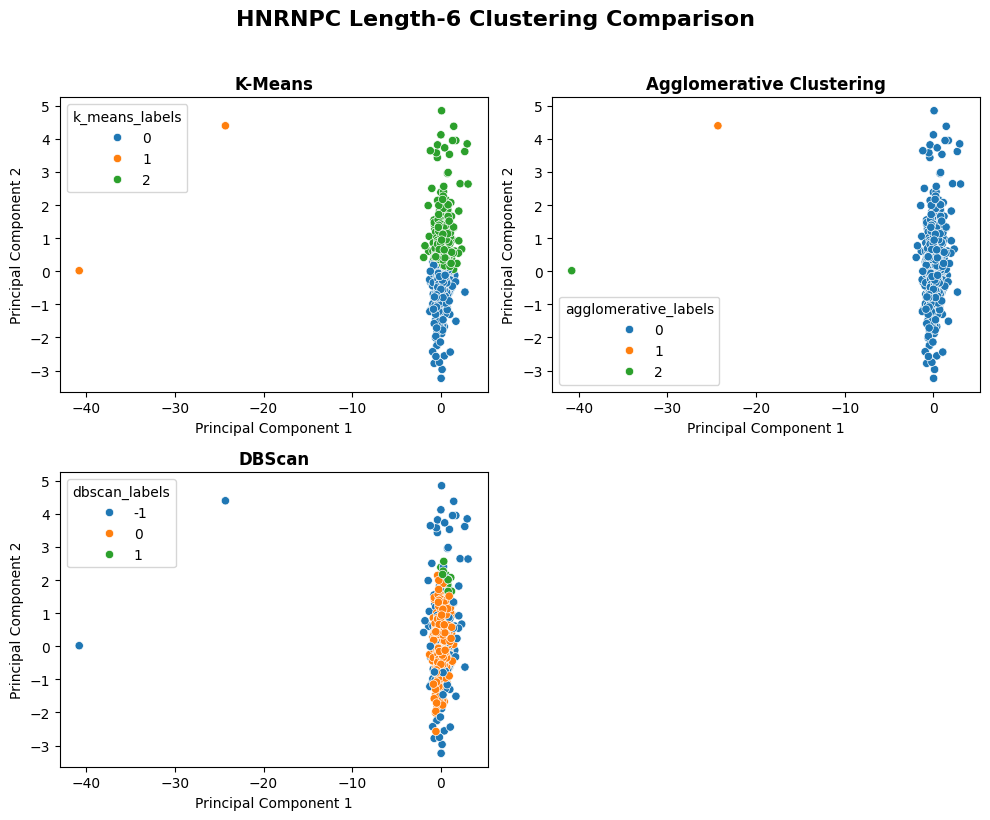

In [32]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan"
}
feature_cols=[f"val{i}" for i in range(1, 7)]

plot_cluster_grid(binding_sites_df_2[6].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPC Length-6 Clustering Comparison")

#### Length 7

In [33]:
best_run_7 = optimize_kmeans(X_7, max_k=20)
binding_sites_df_2[7]["k_means_labels"] = best_run_7["labels"]

Clusters: 3 | Silhouette Score: 0.2895
Clusters: 4 | Silhouette Score: 0.2884
Clusters: 5 | Silhouette Score: 0.2261
Clusters: 6 | Silhouette Score: 0.2358
Clusters: 7 | Silhouette Score: 0.2051
Clusters: 8 | Silhouette Score: 0.2061
Clusters: 9 | Silhouette Score: 0.2111
Clusters: 10 | Silhouette Score: 0.1840
Clusters: 11 | Silhouette Score: 0.1834
Clusters: 12 | Silhouette Score: 0.2061
Clusters: 13 | Silhouette Score: 0.2135
Clusters: 14 | Silhouette Score: 0.1802
Clusters: 15 | Silhouette Score: 0.1725
Clusters: 16 | Silhouette Score: 0.1668
Clusters: 17 | Silhouette Score: 0.1534
Clusters: 18 | Silhouette Score: 0.1526
Clusters: 19 | Silhouette Score: 0.1464
Clusters: 20 | Silhouette Score: 0.1300


In [34]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_7, best_run_7_df = optimize_agglomerative(X_7, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_2[7]["agglomerative_labels"] = best_run_7["labels"]
best_run_7_df.head(5)

,linkage,k,metric,silhouette_score,labels
6,complete,3,euclidean,0.930183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,complete,3,manhattan,0.930183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
25,average,3,manhattan,0.930183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
24,average,3,euclidean,0.930183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.930183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [35]:
best_run_7, best_run_7_df = optimize_dbscan(X_7, eps_range=np.arange(0.1, 1.1, 0.1), min_samples_range=range(3, 10))
binding_sites_df_2[7]["dbscan_labels"] = best_run_7["labels"]
best_run_7_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
25,0.8,6,2,0.166,0.268644,"[-1, -1, 0, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
22,0.7,4,3,0.212,0.150306,"[-1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, ..."
18,0.6,4,2,0.317,0.149791,"[-1, -1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0,..."
24,0.8,4,3,0.141,0.138411,"[-1, -1, 0, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
23,0.7,5,3,0.226,0.137162,"[-1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, ..."


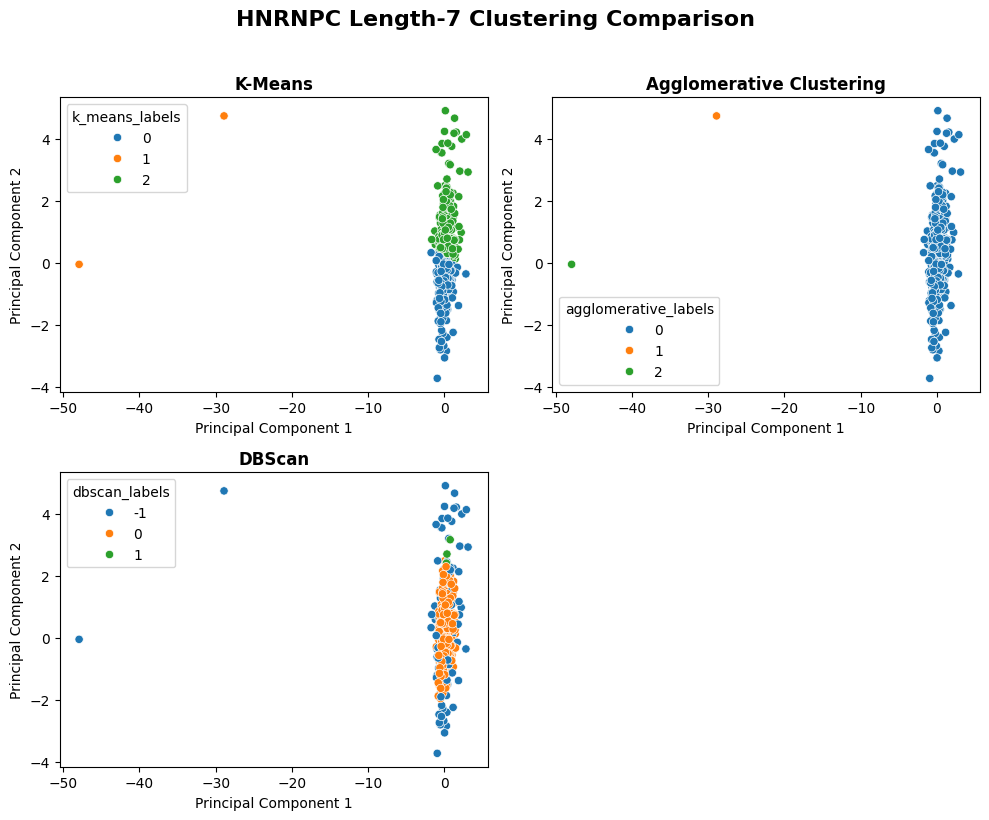

In [36]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan"
}
feature_cols=[f"val{i}" for i in range(1, 8)]

plot_cluster_grid(binding_sites_df_2[7].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPC Length-7 Clustering Comparison")

#### Length 8

In [37]:
best_run_8 = optimize_kmeans(X_8, max_k=20)
binding_sites_df_2[8]["k_means_labels"] = best_run_8["labels"]

Clusters: 3 | Silhouette Score: 0.3034
Clusters: 4 | Silhouette Score: 0.3024
Clusters: 5 | Silhouette Score: 0.2379
Clusters: 6 | Silhouette Score: 0.2235
Clusters: 7 | Silhouette Score: 0.1989
Clusters: 8 | Silhouette Score: 0.1952
Clusters: 9 | Silhouette Score: 0.2011
Clusters: 10 | Silhouette Score: 0.1906
Clusters: 11 | Silhouette Score: 0.1964
Clusters: 12 | Silhouette Score: 0.1853
Clusters: 13 | Silhouette Score: 0.1596
Clusters: 14 | Silhouette Score: 0.1852
Clusters: 15 | Silhouette Score: 0.1484
Clusters: 16 | Silhouette Score: 0.1375
Clusters: 17 | Silhouette Score: 0.1551
Clusters: 18 | Silhouette Score: 0.1727
Clusters: 19 | Silhouette Score: 0.1656
Clusters: 20 | Silhouette Score: 0.1319


In [38]:
linkages = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

best_run_8, best_run_8_df = optimize_agglomerative(X_8, k_range=range(3, 9), linkages=linkages, metrics=metrics)
binding_sites_df_2[8]["agglomerative_labels"] = best_run_8["labels"]
best_run_8_df.head(5)

,linkage,k,metric,silhouette_score,labels
6,complete,3,euclidean,0.946438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,complete,3,manhattan,0.946438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
25,average,3,manhattan,0.946438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
24,average,3,euclidean,0.946438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
42,single,3,euclidean,0.946438,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [39]:
best_run_8, best_run_8_df = optimize_dbscan(X_8, eps_range=np.arange(0.1, 1.1, 0.1), min_samples_range=range(3, 10))
binding_sites_df_2[8]["dbscan_labels"] = best_run_8["labels"]
best_run_8_df.head(5)

,eps,min_samples,n_clusters,noise_ratio,silhouette_score,labels
19,0.8,3,3,0.153,0.209045,"[-1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
21,0.8,5,3,0.175,0.203185,"[-1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
22,0.8,6,3,0.186,0.196613,"[-1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
17,0.7,4,3,0.231,0.169873,"[-1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
16,0.7,3,3,0.222,0.169587,"[-1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0..."


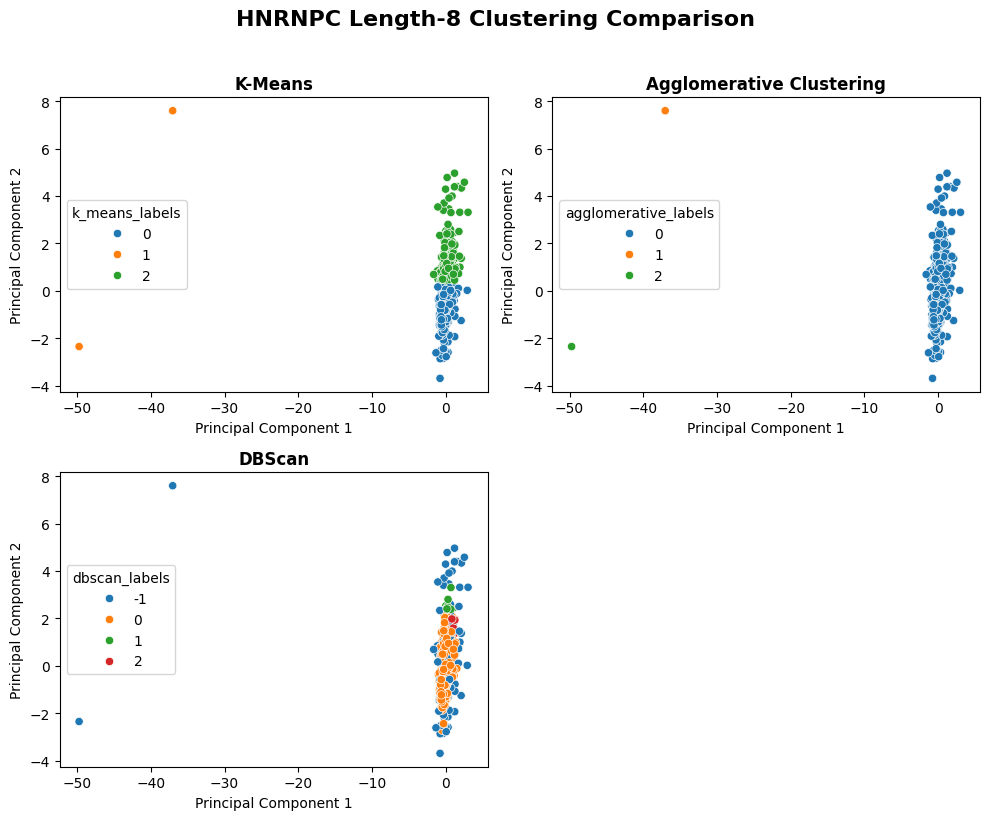

In [40]:
method_map = {
    "k_means_labels": "K-Means",
    "agglomerative_labels": "Agglomerative Clustering",
    "dbscan_labels": "DBScan"
}
feature_cols=[f"val{i}" for i in range(1, 9)]

plot_cluster_grid(binding_sites_df_2[8].drop(columns=["str_representation"]), feature_cols=feature_cols, method_map=method_map, n_cols=2, overall_title="HNRNPC Length-8 Clustering Comparison")

#### Final Results

In [41]:
fshape_dir = Path("./data/AIBI-lab-01-data/RBP-footprinting-data/HNRNPC/hnrnpc_search_fshape")
val_cols = [f"val{i}" for i in range(1, 7)]
base_expected_seq = "".join([char for val, char in motiff_2])
final_findings = []

for window_size in tqdm(motiff_2_lengths):
    top_clusters = get_top_3_clusters(binding_sites_df_2[window_size],
                                      label_col="k_means_labels")
    val_cols = [f"val{i}" for i in range(1, window_size + 1)]
    expected_seq = build_expected_seq(base_expected_seq, window_size)
    final_findings = []

    for cluster_df in top_clusters:
        consensus = get_cluster_consensus(cluster_df, val_cols)
        if consensus is None:
            continue
        for file_path in fshape_dir.glob("*.txt"):
            match_df = search_transcript_for_consensus(
                consensus, file_path, expected_seq
            )
            final_findings.append(match_df)

100%|██████████| 3/3 [00:06<00:00,  2.31s/it]


In [42]:
report_df = pd.concat(final_findings).sort_values('aS')
report_df.head(15)

,motif_sequence,position_range,source_file,znEd,ssf,aS,consensus_used,consensus_len
33,GATGTTGT,1129-1137,hnrnpc_NM_006317_BASP1.txt,0.3378,6,-2.6219,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
117,GGCTGTGC,2527-2535,hnrnpc_NM_001136025_PLS3.txt,0.3963,5,-1.0370,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
0,ACCCATTC,55-63,hnrnpc_NM_133639_RHOV.txt,0.3058,4,-0.9417,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
20,CTTTTTCA,1329-1337,hnrnpc_NM_014214_IMPA2.txt,0.7088,8,-0.9125,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
199,CCCCCTGC,3371-3379,hnrnpc_NM_001875_CPS1.txt,0.4163,5,-0.8371,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
0,AATGTGTC,10-18,hnrnpc_NM_001017365_C4BPB.txt,0.3916,4,-0.0841,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
16,GACCTGAC,812-820,hnrnpc_NM_002901_RCN1.txt,0.4029,4,0.0292,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
22,TCCTTTTT,835-843,hnrnpc_NM_007019_UBE2C.txt,0.7244,7,0.2436,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
26,AGTTTCTA,1281-1289,hnrnpc_NM_020130_C8orf4.txt,0.7415,7,0.4152,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
42,AGATATTT,1552-1560,hnrnpc_NM_006317_BASP1.txt,0.4465,4,0.4649,"[-0.116, -0.128, 0.081, 0.21, -0.207, 0.962, 4...",8
